# Schiet Oranje nog vanaf dezelfde plek als in 1974?

**Auteur:** Amusu Okamoto

Een halve eeuw uit elkaar: van het Oranje van Cruijff (**WK 1974**) via **WK 2022** tot **WK 2026**. De vraag: is "vanaf waar Nederland scoort" een stabiele handtekening, of schuift het mee met spelers, coaches en tactiek?

**Twee analyses:**
1. **Schot-heatmaps** — vanaf waar NL scoorde in 1974, 2022 en 2026 (tot nu toe).
2. **Goal-timing** — in welke minuut viel elke goal, afgezet tegen een eeuw interlandvoetbal.

**Data:** [StatsBomb Open Data](https://github.com/statsbomb/open-data) voor 1974 & 2022 (echte schotlocaties). De WK 2026-goals voer je **handmatig** in (StatsBomb publiceert met maanden vertraging), met een globale veldpositie per goal.

> ⚠️ **Eerlijke kanttekening vooraf:** WK 2026 is voor Oranje nog maar een paar wedstrijden. Dit is dus *verkennend* — een mooie beschrijvende vergelijking, geen harde statistische claim. Met ~5 wedstrijden per toernooi tonen we het patroon, niet een bewijs.

## 1. Setup

In [1]:
import numpy as np, pandas as pd
import urllib.request, json
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from mplsoccer import Pitch

# huisstijl (zelfde als shotmaps-notebook)
PITCH="#0a1f17"; CARD="#0f261c"; NEON="#c6ff3d"; NEON2="#39e6a8"
CHALK="#eafaf1"; MUTE="#7fa892"; DIM="#4d7a64"; LINE="#1d4838"; ORANJE="#ff7a00"
plt.rcParams.update({"figure.facecolor":PITCH,"savefig.facecolor":PITCH,
    "text.color":CHALK,"font.family":"DejaVu Sans"})

## 2. NL-schoten ophalen uit StatsBomb (1974 & 2022)
We pakken alle schoten van Nederland uit de twee toernooien waar NL in zit én StatsBomb dekking heeft. We bewaren minuut, locatie, xG en of het een goal werd.

In [2]:
BASE = "https://raw.githubusercontent.com/statsbomb/open-data/master/data"
NL_TOURNAMENTS = {"WK 1974": (43, 51), "WK 2022": (43, 106)}

def get_json(url):
    with urllib.request.urlopen(url, timeout=60) as r:
        return json.load(r)

def fetch_nl_shots():
    rows = []
    for name, (cid, sid) in NL_TOURNAMENTS.items():
        matches = get_json(f"{BASE}/matches/{cid}/{sid}.json")
        for m in matches:
            teams = (m["home_team"]["home_team_name"], m["away_team"]["away_team_name"])
            if "Netherlands" not in teams:
                continue
            events = get_json(f"{BASE}/events/{m['match_id']}.json")
            for e in events:
                if (e.get("type",{}).get("name")=="Shot"
                        and e["team"]["name"]=="Netherlands"):
                    loc = e.get("location",[None,None]); sh = e["shot"]
                    rows.append({"toernooi":name, "minute":e["minute"],
                        "x":loc[0], "y":loc[1], "xg":sh.get("statsbomb_xg"),
                        "goal":int(sh["outcome"]["name"]=="Goal"),
                        "player":e.get("player",{}).get("name")})
        print(f"{name}: schoten verzameld")
    return pd.DataFrame(rows)

try:
    nl_shots = pd.read_csv("nl_shots_hist.csv")
    print(f"Cache geladen: {len(nl_shots)} schoten")
except FileNotFoundError:
    nl_shots = fetch_nl_shots().dropna(subset=["x","y"])
    nl_shots.to_csv("nl_shots_hist.csv", index=False)
    print(f"Opgehaald: {len(nl_shots)} schoten")

nl_shots.groupby("toernooi").agg(schoten=("x","size"), goals=("goal","sum"))

WK 1974: schoten verzameld
WK 2022: schoten verzameld
Opgehaald: 138 schoten


,schoten,goals
toernooi,,
WK 1974,90,9
WK 2022,48,13


## 3. ✍️ WK 2026 handmatig invoeren

Vul hieronder de **NL-goals van vanavond** in. Per goal twee dingen:
- `min` — de minuut waarin de goal viel
- `zone` — een globaal woord voor de plek (geen coördinaten onthouden)

Beschikbare zones (vanuit NL's aanvalsrichting gezien):
`'links-zestien'`, `'midden-zestien'`, `'rechts-zestien'`, `'penaltystip'`,
`'klein-gebied'` (dichtbij doel), `'rand-zestien'` (net buiten),
`'afstand-links'`, `'afstand-midden'`, `'afstand-rechts'` (van afstand).

> Vul je een **schot** in dat geen goal werd? Zet `goal=0`. Voor alleen de goals laat je `goal=1`.

In [3]:
NL_2026_GOALS = [
    # vs Japan (2-2)
    {"min": 50, "x": 108, "y": 36, "goal": 1, "scorer": "Van Dijk"},
    {"min": 64, "x": 105, "y": 54, "goal": 1, "scorer": "Summerville"},
    # vs Zweden (5-1)
    {"min":  5, "x": 116, "y": 40, "goal": 1, "scorer": "Brobbey"},     # midden vijfmeter
    {"min": 17, "x": 115, "y": 44, "goal": 1, "scorer": "Brobbey"},     # iets rechts van vijfmeter
    {"min": 47, "x": 118, "y": 38, "goal": 1, "scorer": "Gakpo"},       # iets links van vijfmeter
    {"min": 54, "x": 108, "y": 32, "goal": 1, "scorer": "Gakpo"},       # links elfmeter
    {"min": 89, "x": 100, "y": 35, "goal": 1, "scorer": "Summerville"}, # iets links van rand zestien
]

if NL_2026_GOALS:
    nl26 = pd.DataFrame(NL_2026_GOALS)
    nl26["goal"] = nl26.get("goal", 1)        # default 1 als niet opgegeven
    nl26["toernooi"] = "WK 2026"
    print(f"{len(nl26)} NL-goals ingevoerd voor WK 2026:")
    display(nl26[["min", "scorer", "x", "y", "goal"]])
else:
    nl26 = pd.DataFrame(columns=["min", "scorer", "goal", "x", "y", "toernooi"])
    print("Nog geen goals ingevoerd.")

7 NL-goals ingevoerd voor WK 2026:


,min,scorer,x,y,goal
0,50,Van Dijk,108,36,1
1,64,Summerville,105,54,1
2,5,Brobbey,116,40,1
3,17,Brobbey,115,44,1
4,47,Gakpo,118,38,1
5,54,Gakpo,108,32,1
6,89,Summerville,100,35,1


## 4. Drie heatmaps naast elkaar
Vanaf waar scoorde Oranje? Per toernooi de goals (grote stippen) bovenop de schotdichtheid (heatmap). Voor 2026 tonen we de ingevoerde goals — te weinig voor een dichtheidsplot, dus alleen de posities.

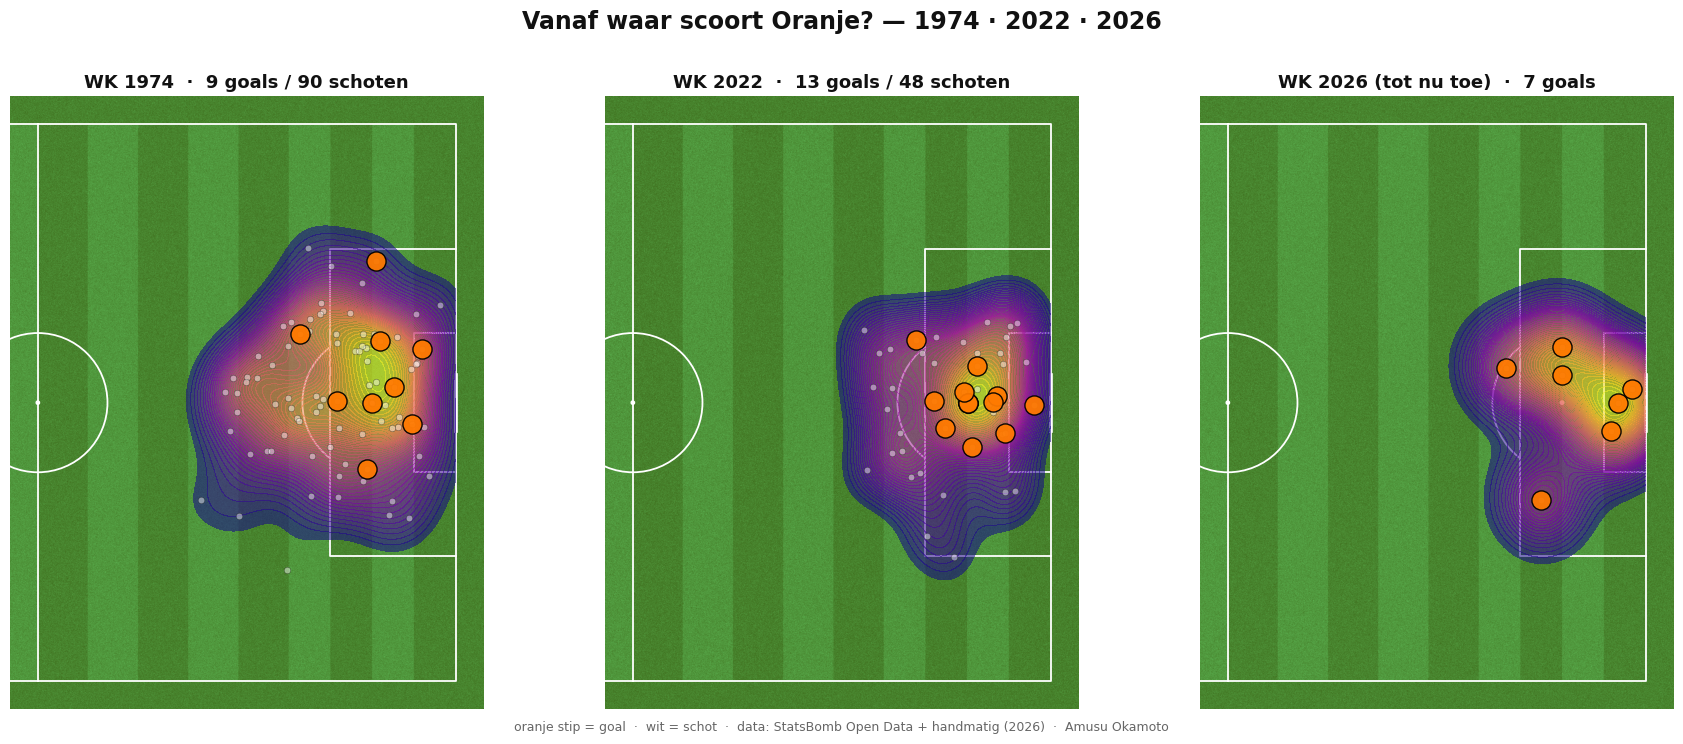

In [4]:
def nl_heatmap(ax, df_shots, df_goals, titel, kde=True):
    pitch = Pitch(pitch_color="grass", line_color="white", stripe=True,
                  half=True, linewidth=1.3)
    pitch.draw(ax=ax)
    if kde and len(df_shots) >= 5:
        pitch.kdeplot(df_shots["x"], df_shots["y"], ax=ax, fill=True,
                      levels=50, cmap="plasma", alpha=0.55, zorder=1)
    # alle schoten klein
    if len(df_shots):
        pitch.scatter(df_shots["x"], df_shots["y"], ax=ax, s=22, color="white",
                      edgecolors="black", linewidth=0.4, alpha=0.45, zorder=2)
    # goals groot/oranje
    if len(df_goals):
        pitch.scatter(df_goals["x"], df_goals["y"], ax=ax, s=190, color=ORANJE,
                      edgecolors="black", linewidth=1.0, alpha=0.95, zorder=3,
                      marker="football" if False else "o")
    ax.set_title(titel, color="#111", fontsize=13, fontweight="bold")

fig, axes = plt.subplots(1, 3, figsize=(18, 7)); fig.patch.set_facecolor("white")

for ax, t in zip(axes[:2], ["WK 1974", "WK 2022"]):
    d = nl_shots[nl_shots["toernooi"]==t]
    nl_heatmap(ax, d, d[d["goal"]==1], f"{t}  ·  {d['goal'].sum()} goals / {len(d)} schoten")

# 2026: alleen goals (handmatig)
g26 = nl26[nl26.get("goal",1)==1] if len(nl26) else nl26
nl_heatmap(axes[2], g26, g26, f"WK 2026 (tot nu toe)  ·  {len(g26)} goals", kde=True)

fig.suptitle("Vanaf waar scoort Oranje? — 1974 · 2022 · 2026",
             color="#111", fontsize=17, fontweight="bold", y=1.02)
fig.text(0.5, -0.01, "oranje stip = goal  ·  wit = schot  ·  data: StatsBomb Open Data + handmatig (2026)  ·  Amusu Okamoto",
         ha="center", color="#666", fontsize=9)
plt.tight_layout()
plt.savefig("nl_heatmaps_1974_2022_2026.png", dpi=130, bbox_inches="tight", facecolor="white")
plt.show()

## 5. Stabiliteit: zelfde zones over de jaren?
We delen de aanvallende helft in een grid en maken per toernooi een genormaliseerd schotprofiel. De correlatie zegt: lijkt het patroon op elkaar? (Met de caveat dat 2026 nog klein is.)

In [5]:
def profile(df, nx=6, ny=5):
    d = df[df["x"] >= 60]
    H,_,_ = np.histogram2d(d["x"], d["y"],
            bins=[np.linspace(60,120,nx+1), np.linspace(0,80,ny+1)])
    v = H.flatten()
    return v/v.sum() if v.sum()>0 else v

prof = {t: profile(nl_shots[nl_shots["toernooi"]==t]) for t in ["WK 1974","WK 2022"]}
if len(nl26):
    prof["WK 2026"] = profile(nl26)

print("Correlatie tussen NL-schotprofielen (hoe hoger, hoe meer dezelfde zones):\n")
pairs = [("WK 1974","WK 2022")]
if "WK 2026" in prof:
    pairs += [("WK 1974","WK 2026"), ("WK 2022","WK 2026")]
for a,b in pairs:
    if prof[a].sum()>0 and prof[b].sum()>0:
        r = pearsonr(prof[a], prof[b])[0]
        print(f"  {a}  vs  {b}:  r = {r:+.3f}")
if "WK 2026" not in prof:
    print("\n(2026 nog niet ingevoerd — vul sectie 3 in voor de volledige vergelijking.)")

Correlatie tussen NL-schotprofielen (hoe hoger, hoe meer dezelfde zones):

  WK 1974  vs  WK 2022:  r = +0.873
  WK 1974  vs  WK 2026:  r = +0.650
  WK 2022  vs  WK 2026:  r = +0.857


## 6. Goal-timing: wanneer scoorde Oranje?
In welke minuut viel elke NL-goal — en volgt dat het ritme van een eeuw interlandvoetbal? We gebruiken de volledige martj42-goalminuten als historisch basispatroon.

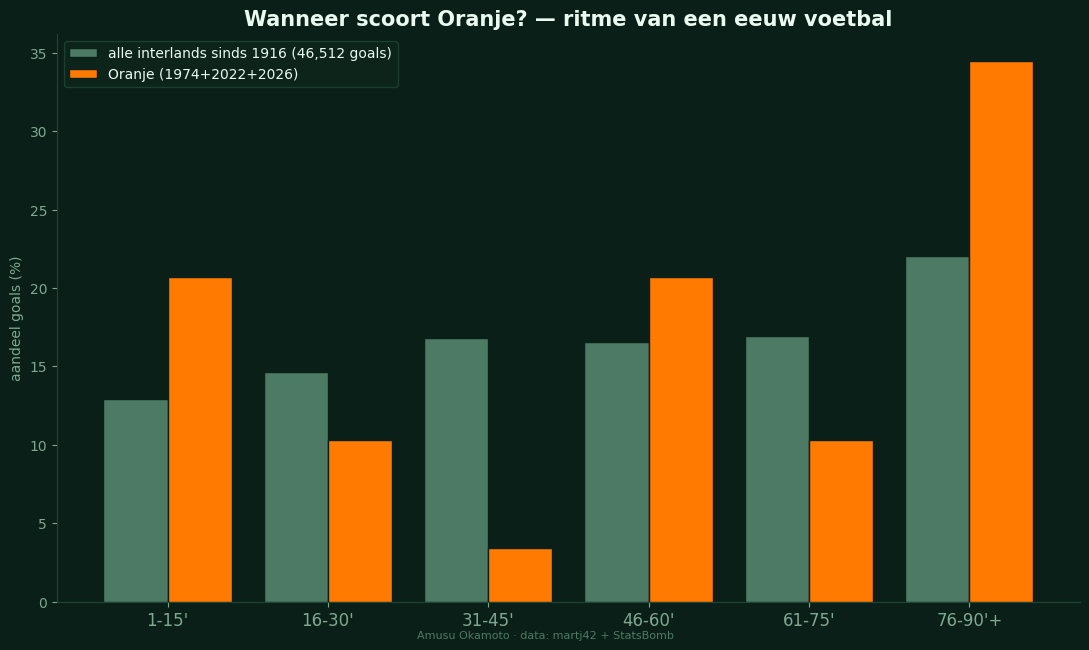

In [6]:
def blok(m):
    if m<=15: return "1-15'"
    if m<=30: return "16-30'"
    if m<=45: return "31-45'"
    if m<=60: return "46-60'"
    if m<=75: return "61-75'"
    return "76-90'+"
BLOK = ["1-15'","16-30'","31-45'","46-60'","61-75'","76-90'+"]

# historisch patroon uit martj42 (alle interlandgoals sinds 1916)
G_URL = "https://raw.githubusercontent.com/martj42/international_results/master/goalscorers.csv"
allgoals = pd.read_csv(G_URL, parse_dates=["date"])
allgoals = allgoals[~allgoals["own_goal"]].dropna(subset=["minute"])
allgoals["fase"] = allgoals["minute"].apply(blok)
hist_dist = (allgoals["fase"].value_counts(normalize=True).reindex(BLOK)*100)

# NL goals: historisch (1974+2022 StatsBomb) + 2026 (handmatig)
nl_hist_goals = nl_shots[nl_shots["goal"]==1].copy()
nl_hist_goals["fase"] = nl_hist_goals["minute"].apply(blok)
nl_min = list(nl_hist_goals["minute"])
if len(nl26):
    nl_min += list(nl26[nl26.get("goal",1)==1]["min"])
nl_series = pd.Series(nl_min).apply(blok).value_counts(normalize=True).reindex(BLOK).fillna(0)*100

fig, ax = plt.subplots(figsize=(11,6.5)); ax.set_facecolor(PITCH)
x = np.arange(len(BLOK)); w=0.4
ax.bar(x-w/2, hist_dist.values, w, label=f"alle interlands sinds 1916 ({len(allgoals):,} goals)",
       color=DIM, edgecolor=PITCH, zorder=3)
ax.bar(x+w/2, nl_series.values, w, label=f"Oranje (1974+2022+2026)", color=ORANJE,
       edgecolor=PITCH, zorder=3)
ax.set_xticks(x); ax.set_xticklabels(BLOK, color=CHALK, fontsize=12)
ax.set_ylabel("aandeel goals (%)", color=MUTE)
for s in ["top","right"]: ax.spines[s].set_visible(False)
for s in ["left","bottom"]: ax.spines[s].set_color(LINE)
ax.tick_params(colors=MUTE)
ax.legend(facecolor=CARD, edgecolor=LINE, labelcolor=CHALK, fontsize=10)
ax.set_title("Wanneer scoort Oranje? — ritme van een eeuw voetbal", color=CHALK,
             fontsize=15, fontweight="bold")
fig.text(0.5, 0.01, "Amusu Okamoto · data: martj42 + StatsBomb", ha="center", color=DIM, fontsize=8)
plt.tight_layout()
plt.savefig("nl_goaltiming.png", dpi=150, bbox_inches="tight")
plt.show()

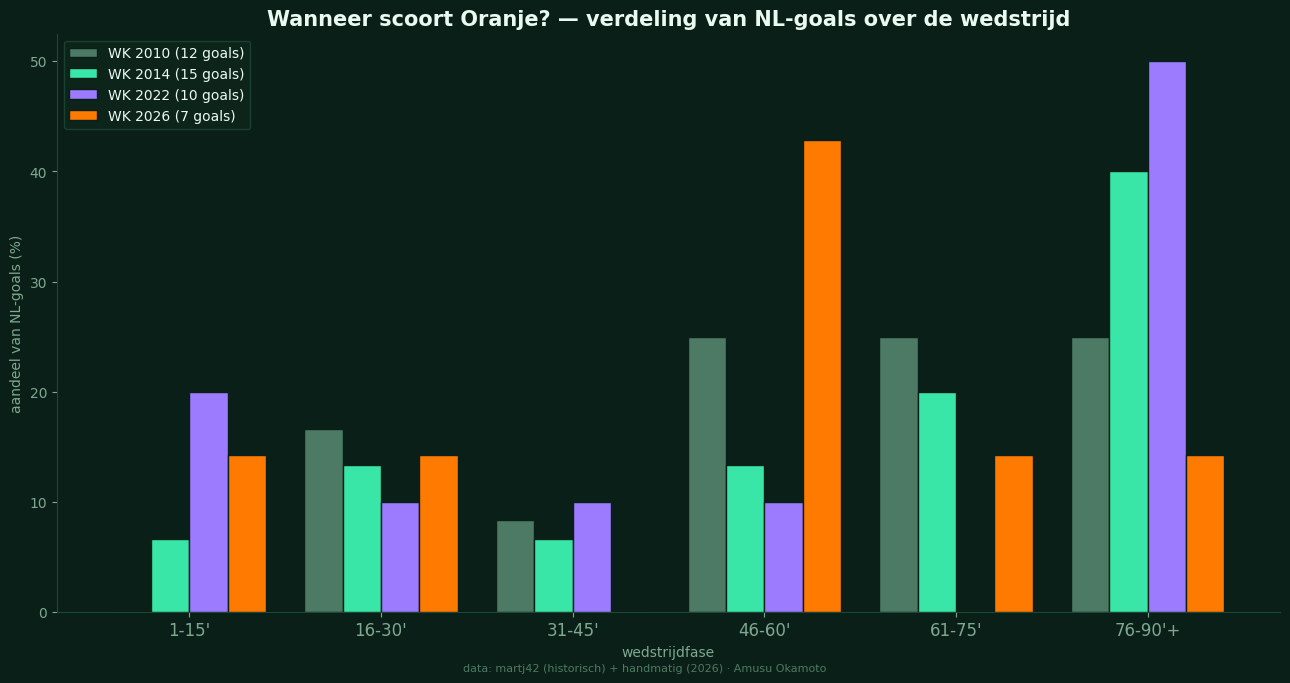

In [ ]:
# === NL goal-timing over meerdere WK's (genormaliseerd, verticale bars) ===
WK_KEUZE = [2010, 2014, 2022, 2026]   # pas aan; NL deed niet mee in 2002 & 2018
INCL_OWN_GOALS = True   # False = alleen NL-spelers (11 in 2010) | True = incl. eigen doelpunt tegenstander (12)

# historische NL-WK-goals uit martj42 (minuut + land voor elk WK)
_g = pd.read_csv("https://raw.githubusercontent.com/martj42/international_results/master/goalscorers.csv",
                 parse_dates=["date"])
_r = pd.read_csv("https://raw.githubusercontent.com/martj42/international_results/master/results.csv",
                 parse_dates=["date"])
_m = _g.merge(_r[["date","home_team","away_team","tournament"]],
              on=["date","home_team","away_team"], how="left")
_mask = (_m["tournament"]=="FIFA World Cup") & (_m["team"]=="Netherlands")
if not INCL_OWN_GOALS:
    _mask &= ~_m["own_goal"]
nl_wc = _m[_mask].dropna(subset=["minute"]).copy()
nl_wc["jaar"] = nl_wc["date"].dt.year

def blok(mn):
    if mn <= 15: return "1-15'"
    if mn <= 30: return "16-30'"
    if mn <= 45: return "31-45'"
    if mn <= 60: return "46-60'"
    if mn <= 75: return "61-75'"
    return "76-90'+"
BLOK = ["1-15'","16-30'","31-45'","46-60'","61-75'","76-90'+"]

# 2026 uit je eigen handmatige invoer (nl26), rest uit martj42
toern = {}
for yr in WK_KEUZE:
    if yr == 2026:
        toern[f"WK {yr}"] = nl26[nl26["goal"]==1]["min"]
    else:
        toern[f"WK {yr}"] = nl_wc[nl_wc["jaar"]==yr]["minute"]

counts = pd.DataFrame({t: pd.Series(list(mn)).apply(blok).value_counts().reindex(BLOK).fillna(0)
                       for t, mn in toern.items()})
pct = counts.div(counts.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(figsize=(13, 6.8)); ax.set_facecolor(PITCH)
labels = list(toern.keys())
palette = [DIM, NEON2, "#9d7bff", ORANJE][:len(labels)]
x = np.arange(len(BLOK)); w = 0.8 / len(labels)
for i, t in enumerate(labels):
    ax.bar(x + i*w - 0.4 + w/2, pct[t].values, w, color=palette[i],
           edgecolor=PITCH, zorder=3, label=f"{t} ({int(counts[t].sum())} goals)")
ax.set_xticks(x); ax.set_xticklabels(BLOK, color=CHALK, fontsize=12)
ax.set_ylabel("aandeel van NL-goals (%)", color=MUTE)
ax.set_xlabel("wedstrijdfase", color=MUTE)
for s in ["top","right"]: ax.spines[s].set_visible(False)
for s in ["left","bottom"]: ax.spines[s].set_color(LINE)
ax.tick_params(colors=MUTE)
ax.legend(facecolor=CARD, edgecolor=LINE, labelcolor=CHALK, fontsize=10)
ax.set_title("Wanneer scoort Oranje? — verdeling van NL-goals over de wedstrijd",
             color=CHALK, fontsize=15, fontweight="bold")
fig.text(0.5, 0.005, "data: martj42 (historisch) + handmatig (2026) · Amusu Okamoto",
         ha="center", color=DIM, fontsize=8)
plt.tight_layout()
plt.savefig("nl_timing_per_wk.png", dpi=140, bbox_inches="tight")
plt.show()

## 7. Wat je hiermee vertelt

Drie deelbare punten, afhankelijk van wat de data straks laat zien:

1. **De heatmaps** — schiet het Oranje van 2026 vanaf dezelfde plekken als dat van 1974? Een halve eeuw, andere spelers, andere tactiek. Wat blijft, is een team-handtekening (of juist niet).
2. **De eerlijke nuance** — schotlocatie lijkt sterk binnen een land, maar bijna élk land schiet centraal voor doel en op de rand van de zestien. Dus: mooie plot, subtiel signaal.
3. **De goal-timing** — het robuuste inzicht. Voetbal is voorspelbaar in zijn *ritme* (oplopend naar de slotfase), veel minder in zijn precieze *uitvoering*.

> Vul sectie 3 in met de echte goals, draai alles opnieuw, en kies de visual die het verhaal het best draagt.